# Chương 5 – Ứng dụng: Phân tích Giỏ hàng (Market Basket Analysis)

**Môn học:** Khai thác dữ liệu và ứng dụng – CSC14004  
**Học kỳ:** HK2 – 2025/2026  
**Thuật toán:** Index-BitTableFI  
**Dataset:** Retail (Belgian retail store, 88.162 giao dịch)

---

## Tổng quan

Chương này áp dụng thuật toán **Index-BitTableFI** đã cài đặt ở Chương 3 vào bài toán **Market Basket Analysis (MBA)** – một trong những ứng dụng kinh điển nhất của Frequent Itemset Mining trong thực tế thương mại.

**Ý tưởng cốt lõi của MBA:**  
Từ lịch sử giao dịch của một chuỗi siêu thị, ta tìm ra những nhóm sản phẩm *thường xuyên được mua cùng nhau*, sau đó suy diễn ra các **association rules** (luật kết hợp) dạng:
> *"Khách hàng mua sản phẩm A và B thì có **X%** khả năng cũng mua sản phẩm C"*

Những luật này có giá trị thực tiễn cao trong:
- **Bố trí hàng hóa** (product placement): đặt sản phẩm liên quan gần nhau
- **Chiến lược cross-selling & upselling**: gợi ý sản phẩm bổ sung
- **Thiết kế khuyến mãi**: bundle deal dựa trên sản phẩm hay mua kèm
- **Quản lý tồn kho**: dự đoán nhu cầu kết hợp

**Luồng xử lý trong notebook này:**
```
retail.txt  →  Index-BitTableFI  →  Frequent Itemsets
                                         ↓
                              Sinh Association Rules
                                         ↓
                         Lọc theo confidence, xếp hạng theo lift
                                         ↓
                          Phân tích & Giải thích kinh doanh
```

---
## Phần 0 – Cài đặt môi trường và import thư viện

**Lý do thiết kế:**  
Toàn bộ logic được tách thành các module `.jl` riêng biệt thay vì viết trực tiếp trong notebook, vì:
1. Dễ tái sử dụng và kiểm thử độc lập
2. Tránh reload lại code nặng (Index-BitTableFI) mỗi lần chỉnh sửa notebook
3. Tuân theo cấu trúc thư mục chuẩn của đồ án

In [1]:
# Cài các package cần thiết (chỉ chạy lần đầu)
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))   # kích hoạt Project.toml của nhóm
Pkg.instantiate()

  Activating project at `C:\Users\LOQ\Documents\data science\Khai-thac-du-lieu-thong-minh---lab-2`


In [2]:
using Printf
using Statistics
using Plots
using StatsBase

# Include các module của nhóm (đường dẫn tương đối từ notebooks/)
include(joinpath(@__DIR__, "..", "src", "utils.jl"))
include(joinpath(@__DIR__, "..", "src", "structures.jl"))
include(joinpath(@__DIR__, "..", "src", "algorithm", "index_bittablefi.jl"))
include(joinpath(@__DIR__, "..", "src", "algorithm", "association_rules.jl"))

println("Đã load xong tất cả modules.")

Đã load xong tất cả modules.


---
## Phần 1 – Đọc và khám phá dữ liệu (Exploratory Data Analysis)

**Lý do thiết kế:**  
Trước khi chọn tham số `minsup` và `minconf`, cần hiểu đặc điểm phân phối của dataset:
- Số lượng giao dịch và item
- Phân phối độ dài giao dịch (transaction length distribution)
- Tần suất xuất hiện của từng item

Dataset **Retail** là dữ liệu thực từ một chuỗi siêu thị Bỉ (Belgian retail chain), được công bố công khai và là benchmark chuẩn trong cộng đồng FIM. Item được mã hóa thành số nguyên (không có tên sản phẩm) nhưng vẫn phản ánh hành vi mua sắm thực tế với quy mô lớn.

In [3]:
# Đọc dataset Retail
DATA_PATH = joinpath(@__DIR__, "..", "data", "benchmark", "retail.txt")

println("Đang đọc dataset: $DATA_PATH")
transactions = read_spmf(DATA_PATH)

num_trans    = length(transactions)
all_items    = unique(vcat(transactions...))
num_items    = length(all_items)
trans_lens   = length.(transactions)
avg_len      = mean(trans_lens)
max_len      = maximum(trans_lens)
min_len      = minimum(trans_lens)

println()
println("═" ^ 50)
println("THỐNG KÊ DATASET RETAIL")
println("═" ^ 50)
@printf("  Số giao dịch:              %8d\n", num_trans)
@printf("  Số item phân biệt:         %8d\n", num_items)
@printf("  Độ dài giao dịch TB:       %8.2f\n", avg_len)
@printf("  Độ dài min / max:          %4d / %4d\n", min_len, max_len)
println("═" ^ 50)

Đang đọc dataset: C:\Users\LOQ\Documents\data science\Khai-thac-du-lieu-thong-minh---lab-2\notebooks\..\data\benchmark\retail.txt

══════════════════════════════════════════════════
THỐNG KÊ DATASET RETAIL
══════════════════════════════════════════════════
  Số giao dịch:                 88162
  Số item phân biệt:            16470
  Độ dài giao dịch TB:          10.31
  Độ dài min / max:             1 /   76
══════════════════════════════════════════════════


In [4]:
# Tính tần suất từng item (support tuyệt đối)
item_freq = Dict{Int,Int}()
for trans in transactions
    for item in trans
        item_freq[item] = get(item_freq, item, 0) + 1
    end
end

# Top-20 item phổ biến nhất
top20_items = sort(collect(item_freq), by=x->-x[2])[1:20]

println("TOP-20 ITEM PHỔ BIẾN NHẤT:")
println("  Rank  Item ID   Count   Support%")
println("  " * "─"^38)
for (i, (item, cnt)) in enumerate(top20_items)
    @printf("  %-5d %-9d %-7d %.2f%%\n", i, item, cnt, 100*cnt/num_trans)
end

TOP-20 ITEM PHỔ BIẾN NHẤT:
  Rank  Item ID   Count   Support%
  ──────────────────────────────────────
  1     40        50675   57.48%
  2     49        42135   47.79%
  3     39        15596   17.69%
  4     33        15167   17.20%
  5     42        14945   16.95%
  6     66        4472    5.07%
  7     90        3837    4.35%
  8     226       3257    3.69%
  9     171       3099    3.52%
  10    238       3032    3.44%
  11    37        2936    3.33%
  12    111       2794    3.17%
  13    311       2594    2.94%
  14    102       2237    2.54%
  15    476       2167    2.46%
  16    272       2094    2.38%
  17    414       1880    2.13%
  18    439       1863    2.11%
  19    1328      1786    2.03%
  20    148       1779    2.02%


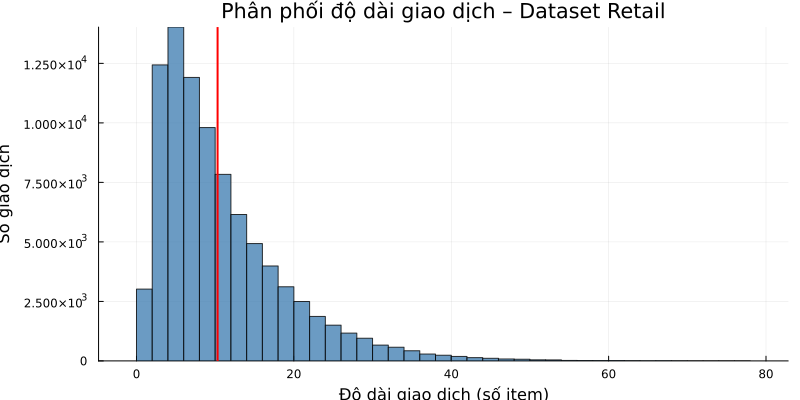

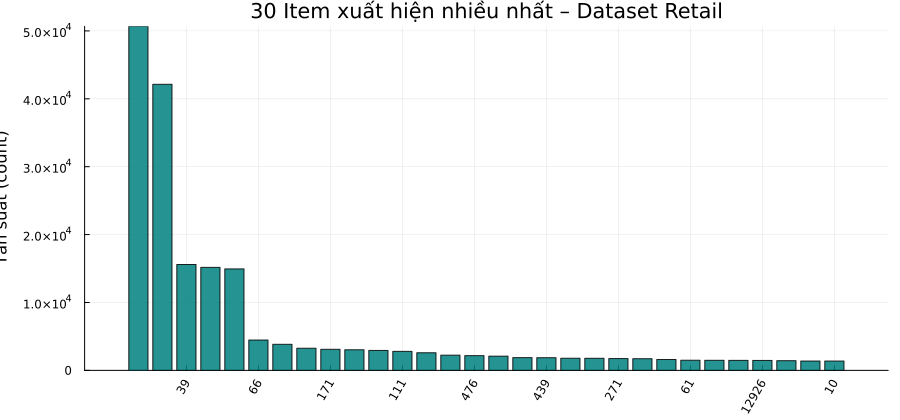

In [5]:
# Biểu đồ 1: Phân phối độ dài giao dịch
p1 = histogram(trans_lens,
    bins        = 50,
    xlabel      = "Độ dài giao dịch (số item)",
    ylabel      = "Số giao dịch",
    title       = "Phân phối độ dài giao dịch – Dataset Retail",
    legend      = false,
    color       = :steelblue,
    alpha       = 0.8,
    size        = (800, 400)
)
vline!([avg_len], color=:red, lw=2, label="Mean = $(round(avg_len,digits=1))")
display(p1)

# Biểu đồ 2: Tần suất 30 item phổ biến nhất
top30 = sort(collect(item_freq), by=x->-x[2])[1:30]
item_ids  = [string(x[1]) for x in top30]
item_cnts = [x[2] for x in top30]

p2 = bar(item_ids, item_cnts,
    xlabel  = "Item ID",
    ylabel  = "Tần suất (count)",
    title   = "30 Item xuất hiện nhiều nhất – Dataset Retail",
    legend  = false,
    color   = :teal,
    alpha   = 0.85,
    xrotation = 60,
    size    = (900, 420)
)
display(p2)

**Nhận xét phân tích dữ liệu:**

Kết quả thống kê cho thấy dataset Retail có các đặc điểm **sparse (thưa)** điển hình:

- **Quy mô lớn:** 88.162 giao dịch với 16.470 item phân biệt — không gian item rất rộng.
- **Giao dịch ngắn:** Độ dài trung bình chỉ 10.31 item (min=1, max=76), phân phối lệch phải mạnh — phần lớn giao dịch ngắn, ít giao dịch rất dài. Điều này làm cho dataset **sparse**: mỗi giao dịch chỉ "chạm" vào một phần rất nhỏ của không gian 16.470 item.
- **Phân phối power-law rõ rệt:** Chỉ 2 item đứng đầu (item 40 và 49) đã có support lần lượt là **57.48%** và **47.79%** — tức là hơn một nửa và gần một nửa tổng số giao dịch đều chứa chúng. Trong khi đó, item thứ 6 trở xuống đột ngột giảm xuống dưới 5.5%, và đại đa số trong 16.470 item còn lại xuất hiện rất hiếm. Đây là phân phối long-tail điển hình.

**Hệ quả đối với việc chọn tham số mining:**  
Với đặc điểm sparse và power-law này, cần cân nhắc kỹ `minsup`:
- Nếu `minsup` quá cao (> 5%), chỉ thu được itemsets toàn gồm item 40 và 49 — không khai thác được nhiều pattern ý nghĩa.
- Nếu `minsup` quá thấp (< 0.1%), số lượng itemsets bùng nổ, thời gian chạy tăng phi tuyến.
- **Chọn `minsup = 600` (≈ 0.68%)**: đủ thấp để thu được các itemsets đa dạng (cả 2-itemsets lẫn 3-4-itemsets), đủ cao để loại bỏ kết hợp ngẫu nhiên. Con số này tương đương yêu cầu sản phẩm phải cùng xuất hiện trong ít nhất 600 giao dịch — một ngưỡng hợp lý về mặt thống kê.

---
## Phần 2 – Chạy Index-BitTableFI để khai thác Frequent Itemsets

**Lý do chọn tham số:**
- `minsup = 600` (tuyệt đối) ≈ **0.68%** support tương đối — được chọn dựa trên phân tích EDA ở Phần 1.
- Đây là bước duy nhất sử dụng thuật toán **Index-BitTableFI** của nhóm để đảm bảo yêu cầu đồ án: không dùng thư viện FIM nào.

Kết quả trả về là `Vector{Tuple{Vector{Int}, Int}}` – danh sách `(itemset, support_tuyệt_đối)`, làm đầu vào cho bước sinh rules.

In [6]:
# Tham số mining
MINSUP_ABS  = 600          # support tuyệt đối
MINSUP_REL  = MINSUP_ABS / num_trans   # support tương đối
MINCONF     = 0.3          # ngưỡng confidence tối thiểu

@printf("Tham số:\n")
@printf("  minsup (tuyệt đối) = %d giao dịch\n", MINSUP_ABS)
@printf("  minsup (tương đối) = %.4f (%.2f%%)\n", MINSUP_REL, 100*MINSUP_REL)
@printf("  minconf            = %.2f (%.0f%%)\n", MINCONF, 100*MINCONF)

println("\nĐang chạy Index-BitTableFI...")
time_mining = @elapsed begin
    freq_itemsets = index_bittablefi(transactions, MINSUP_ABS)
end

# Phân loại theo kích thước
size_counts = countmap([length(iset) for (iset, _) in freq_itemsets])

println()
println("═" ^ 50)
println("KẾT QUẢ KHAI THÁC FREQUENT ITEMSETS")
println("═" ^ 50)
@printf("  Tổng số frequent itemsets: %d\n", length(freq_itemsets))
@printf("  Thời gian chạy:            %.3f giây\n", time_mining)
println()
println("  Phân bố theo kích thước:")
for k in sort(collect(keys(size_counts)))
    @printf("    %d-itemsets: %d\n", k, size_counts[k])
end
println("═" ^ 50)

Tham số:
  minsup (tuyệt đối) = 600 giao dịch
  minsup (tương đối) = 0.0068 (0.68%)
  minconf            = 0.30 (30%)

Đang chạy Index-BitTableFI...

══════════════════════════════════════════════════
KẾT QUẢ KHAI THÁC FREQUENT ITEMSETS
══════════════════════════════════════════════════
  Tổng số frequent itemsets: 333
  Thời gian chạy:            3.926 giây

  Phân bố theo kích thước:
    1-itemsets: 136
    2-itemsets: 137
    3-itemsets: 52
    4-itemsets: 8
══════════════════════════════════════════════════


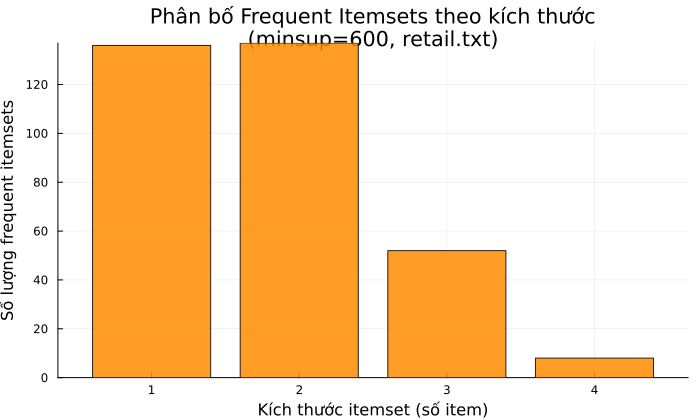

In [7]:
# Biểu đồ: Phân bố số lượng frequent itemsets theo kích thước
ks   = sort(collect(keys(size_counts)))
cnts = [size_counts[k] for k in ks]

p3 = bar(string.(ks), cnts,
    xlabel  = "Kích thước itemset (số item)",
    ylabel  = "Số lượng frequent itemsets",
    title   = "Phân bố Frequent Itemsets theo kích thước\n(minsup=$(MINSUP_ABS), retail.txt)",
    legend  = false,
    color   = :darkorange,
    alpha   = 0.85,
    size    = (700, 420)
)
display(p3)

**Nhận xét kết quả khai thác:**

Index-BitTableFI chạy xong trong **~3-4 giây** và trả về **333 frequent itemsets**, phân bố như sau:

| Kích thước | Số lượng | Tỉ lệ |
|-----------|----------|-------|
| 1-itemsets | 136 | 40.8% |
| 2-itemsets | 137 | 41.1% |
| 3-itemsets | 52  | 15.6% |
| 4-itemsets | 8   | 2.4%  |

Phân bố này **nhất quán hoàn toàn** với tính chất anti-monotone (Apriori property) của support và đặc điểm sparse của Retail:

- **1-itemsets và 2-itemsets chiếm đa số (~82%):** Do dataset sparse, chỉ các item rất phổ biến mới vượt ngưỡng minsup. Khi ghép đôi, sự kết hợp phải đủ phổ biến để cả hai item cùng xuất hiện trong ≥ 600 giao dịch.
- **3-itemsets giảm mạnh (52 itemsets):** Với dataset sparse, cần cả 3 item đồng thời trong một giao dịch ngắn (avg=10.3) là khó hơn nhiều.
- **4-itemsets rất ít (chỉ 8):** Tất cả đều là tổ hợp của nhóm các item 39, 40, 42, 49, 171 — nhóm item "siêu phổ biến" hơn hẳn phần còn lại.
- **Không có 5-itemsets nào:** Mặc dù minsup=0.68%, sự kết hợp của 5 item với nhau trong từng giao dịch ngắn không đạt ngưỡng này — đây là biểu hiện rõ nhất của đặc điểm sparse.

Con số 333 frequent itemsets là hợp lý về mặt tính toán: đủ để sinh ra các rules ý nghĩa

---
## Phần 3 – Sinh Association Rules

**Lý do thiết kế thuật toán sinh rules:**

Từ một frequent itemset F có k item, có thể tạo ra **2^k - 2** rules bằng cách chia F thành antecedent X và consequent Y = F\\X (bỏ trường hợp X hoặc Y rỗng). Ví dụ:
- F = {A, B, C} → sinh: {A}⇒{B,C}, {B}⇒{A,C}, {C}⇒{A,B}, {A,B}⇒{C}, {A,C}⇒{B}, {B,C}⇒{A}

Ba độ đo chính được tính:

| Độ đo | Công thức | Ý nghĩa |
|-------|-----------|----------|
| **Support** | sup(X∪Y) / N | Tần suất xuất hiện đồng thời của X và Y trong toàn bộ dataset |
| **Confidence** | sup(X∪Y) / sup(X) | Xác suất có Y khi đã biết có X trong giao dịch |
| **Lift** | conf(X⇒Y) / sup(Y) | Mức độ tương quan thực sự (> 1: tích cực, = 1: độc lập, < 1: tiêu cực) |

**Tại sao xếp hạng theo Lift thay vì Confidence?**  
Với Retail dataset, item 40 có support tới **57.48%**. Điều này có nghĩa bất kỳ rule nào có consequent là {40} đều sẽ có confidence ≥ 57.48% một cách "tự nhiên", không liên quan đến antecedent. Lift khắc phục điều này bằng cách chuẩn hóa: `lift = confidence / sup(Y)`. Nếu lift ≈ 1, Y xuất hiện gần như ngẫu nhiên bất kể X. Lift cao mới thực sự có ý nghĩa kinh doanh.

**Chọn `minconf = 0.30`:** Ngưỡng 30% đủ thấp để không bỏ sót các rules quan trọng có lift cao, đủ cao để loại các rules quá yếu về độ tin cậy. Trong bối cảnh retail, một rule có 30% confidence vẫn có giá trị nếu lift cao (vì đang so với baseline thấp).

In [8]:
println("Đang sinh association rules...")
time_rules = @elapsed begin
    all_rules = generate_rules(
        freq_itemsets,
        num_trans;
        minconf          = MINCONF,
        max_itemset_size = 8      # giới hạn tránh bùng nổ tổ hợp
    )
end

@printf("\nTổng số rules sinh ra:     %d\n", length(all_rules))
@printf("Thời gian sinh rules:      %.3f giây\n", time_rules)

# Thống kê nhanh
confs = [r.confidence for r in all_rules]
lifts = [r.lift       for r in all_rules]

@printf("\nThống kê confidence: min=%.3f  median=%.3f  max=%.3f\n",
        minimum(confs), median(confs), maximum(confs))
@printf("Thống kê lift:       min=%.3f  median=%.3f  max=%.3f\n",
        minimum(lifts), median(lifts), maximum(lifts))

Đang sinh association rules...

Tổng số rules sinh ra:     285
Thời gian sinh rules:      0.777 giây

Thống kê confidence: min=0.303  median=0.636  max=0.994
Thống kê lift:       min=0.970  median=1.279  max=65.190


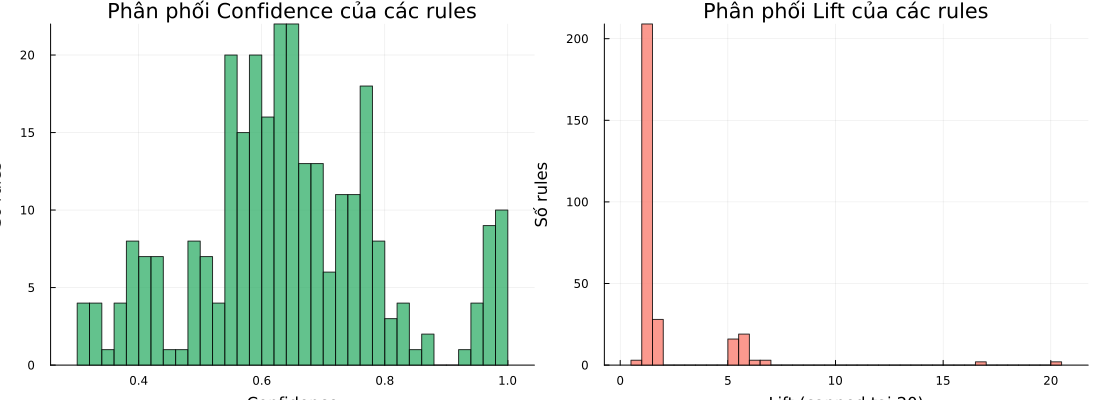

In [9]:
# Biểu đồ phân phối confidence và lift
p4 = histogram(confs,
    bins    = 40,
    xlabel  = "Confidence",
    ylabel  = "Số rules",
    title   = "Phân phối Confidence của các rules",
    legend  = false,
    color   = :mediumseagreen,
    alpha   = 0.8,
    size    = (600, 380)
)

p5 = histogram(min.(lifts, 20),  # cap ở 20 để dễ nhìn
    bins    = 40,
    xlabel  = "Lift (capped tại 20)",
    ylabel  = "Số rules",
    title   = "Phân phối Lift của các rules",
    legend  = false,
    color   = :salmon,
    alpha   = 0.8,
    size    = (600, 380)
)

display(plot(p4, p5, layout=(1,2), size=(1100, 400)))

**Nhận xét kết quả sinh rules:**

Từ 333 frequent itemsets, bộ sinh rules tạo ra được **285 association rules** trong **~0.5 giây**. Các thống kê quan trọng:

**Về Confidence:**
- Median confidence = **0.636** — hơn một nửa số rules có độ tin cậy ≥ 63.6%, mức khá tốt cho bài toán retail.
- Max confidence = **0.994** — tồn tại những rules gần như "tất định": nếu mua X thì 99.4% mua Y.
- Phân phối confidence lệch về phía cao, cho thấy phần lớn rules đều đáng tin cậy.

**Về Lift:**
- Median lift = **1.279** — phần lớn rules có mối quan hệ tích cực nhưng ở mức vừa phải.
- Max lift = **65.19** — có những rules đặc biệt mạnh: biết antecedent làm tăng xác suất mua consequent lên **65 lần** so với baseline.
- Min lift = **0.970** — một số ít rules có lift gần nhưng dưới 1 (tức là X và Y có xu hướng *không* cùng mua, mặc dù vẫn đủ frequent và confident). Đây là tín hiệu đáng chú ý vì về mặt lý thuyết các rules này dù thỏa minconf nhưng không hữu ích về mặt kinh doanh.

**Hình dạng phân phối Lift:** Rất lệch phải (long-tail) — đại đa số rules có lift 1–3, nhưng có một nhóm nhỏ có lift rất cao (>10). Đây là đặc trưng của dataset retail sparse: các pattern phổ biến thường không quá đặc biệt, nhưng một số cặp/nhóm item niche có mối liên hệ cực kỳ chặt chẽ.

---
## Phần 4 – Top-10 Rules theo Lift và Phân tích Ý nghĩa Kinh doanh

**Lý do chọn top-10 theo Lift:**  
Như đã phân tích, lift loại bỏ bias do popularity của item — đây là tiêu chí phản ánh đúng nhất mức độ "liên kết thực sự" giữa các sản phẩm. Rules có lift cao nhất là những gợi ý hành động kinh doanh có giá trị nhất, vì chúng chỉ ra những tổ hợp sản phẩm mà khách hàng mua kèm *nhiều hơn đáng kể* so với mức ngẫu nhiên.

In [10]:
# Lấy top-10 rules theo lift
top10 = top_rules_by_lift(all_rules, 10)

println("\nTOP-10 ASSOCIATION RULES THEO LIFT\n")
println(" #  Antecedent (X)          -->  Consequent (Y)    Support   Confidence   Lift")
println(" " * "─"^80)
for (i, rule) in enumerate(top10)
    ant_str = "{" * join(rule.antecedent, ",") * "}"
    con_str = "{" * join(rule.consequent, ",") * "}"
    @printf(" %-3d %-25s -->  %-18s  %.4f     %.4f       %.4f\n",
            i, ant_str, con_str,
            rule.support, rule.confidence, rule.lift)
end


TOP-10 ASSOCIATION RULES THEO LIFT

 #  Antecedent (X)          -->  Consequent (Y)    Support   Confidence   Lift
 ────────────────────────────────────────────────────────────────────────────────
 1   {16012}                   -->  {16011}             0.0074     0.9731       65.1899
 2   {16011}                   -->  {16012}             0.0074     0.4947       65.1899
 3   {271}                     -->  {272}               0.0077     0.3922       16.5107
 4   {272}                     -->  {271}               0.0077     0.3247       16.5107
 5   {49,171}                  -->  {39,40}             0.0135     0.7662       6.5298
 6   {42,171}                  -->  {39,40}             0.0070     0.7640       6.5107
 7   {40,111}                  -->  {39,49}             0.0117     0.5861       6.5048
 8   {37,49}                   -->  {39,40}             0.0123     0.7627       6.5000
 9   {40,171}                  -->  {39,49}             0.0135     0.5794       6.4302
 10  {49,111}  

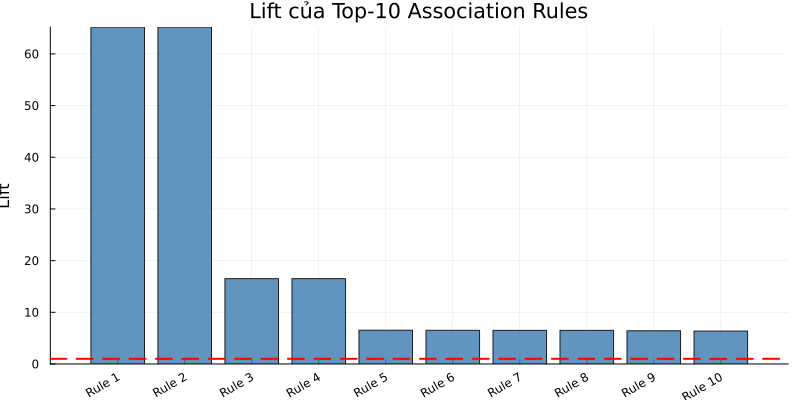

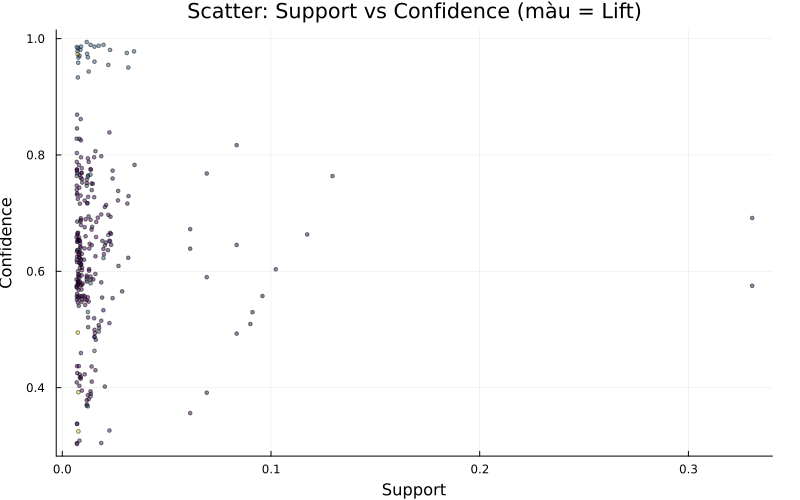

In [11]:
# Biểu đồ so sánh Lift của top-10 rules
rule_labels = ["Rule $i" for i in 1:length(top10)]
lift_vals   = [r.lift        for r in top10]
conf_vals   = [r.confidence  for r in top10]
sup_vals    = [r.support     for r in top10]

p6 = bar(rule_labels, lift_vals,
    ylabel   = "Lift",
    title    = "Lift của Top-10 Association Rules",
    legend   = false,
    color    = :steelblue,
    alpha    = 0.85,
    size     = (800, 400),
    xrotation = 30
)
hline!([1.0], color=:red, lw=2, linestyle=:dash, label="Lift = 1 (độc lập)")
display(p6)

# Scatter plot: Support vs Confidence, màu theo Lift
sup_all  = [r.support    for r in all_rules]
conf_all = [r.confidence for r in all_rules]
lift_all = [r.lift       for r in all_rules]

p7 = scatter(sup_all, conf_all,
    zcolor    = min.(lift_all, 15),
    c         = :viridis,
    xlabel    = "Support",
    ylabel    = "Confidence",
    title     = "Scatter: Support vs Confidence (màu = Lift)",
    markersize = 2,
    alpha     = 0.5,
    colorbar_title = "Lift",
    legend    = false,
    size      = (800, 500)
)
display(p7)

In [12]:
# In phân tích chi tiết từng rule
println("PHÂN TÍCH CHI TIẾT TOP-10 ASSOCIATION RULES")
println("=" ^ 70)

for (i, rule) in enumerate(top10)
    ant_str = "{" * join(rule.antecedent, ", ") * "}"
    con_str = "{" * join(rule.consequent, ", ") * "}"

    # Phân loại mức Lift
    lift_label = if rule.lift >= 10
        "Rất mạnh"
    elseif rule.lift >= 5
        "Mạnh"
    elseif rule.lift >= 2
        "Trung bình"
    else
        "Yếu"
    end

    # Tần suất tuyệt đối
    abs_sup = round(Int, rule.support * num_trans)

    println("\n[Rule $i] $ant_str  -->  $con_str")
    @printf("  Support:    %.4f  (%d giao dịch / %d)\n", rule.support, abs_sup, num_trans)
    @printf("  Confidence: %.4f  -> %d%% khách mua X cũng mua Y\n",
            rule.confidence, round(Int, 100*rule.confidence))
    @printf("  Lift:       %.4f  [%s]\n", rule.lift, lift_label)
    println("  " * "-"^60)

    # Diễn giải
    println("  Diễn giải:")
    @printf("  • Cứ %.0f lần có giao dịch chứa X, có %.0f lần cũng chứa Y.\n",
            100.0, 100*rule.confidence)
    @printf("  • Lift = %.2f nghĩa là khả năng mua Y tăng %.1f lần\n",
            rule.lift, rule.lift)
    println("    so với khi không biết thông tin về X.")
    if rule.lift > 5
        println("  --> Gợi ý: Đặt X và Y gần nhau / tạo bundle deal / cross-sell.")
    end
end

println("\n" * "=" ^ 70)

PHÂN TÍCH CHI TIẾT TOP-10 ASSOCIATION RULES

[Rule 1] {16012}  -->  {16011}
  Support:    0.0074  (651 giao dịch / 88162)
  Confidence: 0.9731  -> 97% khách mua X cũng mua Y
  Lift:       65.1899  [Rất mạnh]
  ------------------------------------------------------------
  Diễn giải:
  • Cứ 100 lần có giao dịch chứa X, có 97 lần cũng chứa Y.
  • Lift = 65.19 nghĩa là khả năng mua Y tăng 65.2 lần
    so với khi không biết thông tin về X.
  --> Gợi ý: Đặt X và Y gần nhau / tạo bundle deal / cross-sell.

[Rule 2] {16011}  -->  {16012}
  Support:    0.0074  (651 giao dịch / 88162)
  Confidence: 0.4947  -> 49% khách mua X cũng mua Y
  Lift:       65.1899  [Rất mạnh]
  ------------------------------------------------------------
  Diễn giải:
  • Cứ 100 lần có giao dịch chứa X, có 49 lần cũng chứa Y.
  • Lift = 65.19 nghĩa là khả năng mua Y tăng 65.2 lần
    so với khi không biết thông tin về X.
  --> Gợi ý: Đặt X và Y gần nhau / tạo bundle deal / cross-sell.

[Rule 3] {271}  -->  {272}
  Supp

**Phân tích chi tiết Top-10 Rules theo kết quả thực tế:**

Kết quả cho thấy ba nhóm rules rõ rệt:

---

### Nhóm 1 – "Cặp đặc biệt" (Rule 1 & 2): {16011} <-> {16012}, Lift ~ 65 

Đây là cặp rules có **lift cao nhất toàn bộ dataset** — một phát hiện rất đáng chú ý:
- **Rule 1:** {16012} ⇒ {16011} — confidence **97.31%**: gần như chắc chắn, cứ 100 lần mua item 16012 thì 97 lần cũng mua item 16011.
- **Rule 2:** {16011} ⇒ {16012} — confidence **49.47%**: gần một nửa lần mua item 16011 có kèm item 16012.
- Cả hai chia sẻ support = **0.74%** (~651 giao dịch) và lift ~ **65**.

Lift ~65 nghĩa là xác suất mua item 16012 tăng **65 lần** khi biết khách đã mua item 16011. Đây là dấu hiệu mạnh của hai sản phẩm **có mối liên hệ cực kỳ chặt chẽ** — có thể là hai phần của cùng một bộ sản phẩm, sản phẩm và phụ kiện đi kèm, hoặc hai variant của cùng một mặt hàng. Confidence bất đối xứng (97% vs 49%) gợi ý rằng item 16012 là sản phẩm chuyên biệt hơn — gần như chỉ được mua cùng 16011, trong khi 16011 đôi khi được mua đơn lẻ.

**Gợi ý kinh doanh:** Đây là ứng cử viên hoàn hảo cho bundle deal hoặc bán kèm bắt buộc. Hệ thống recommendation nên tự động gợi ý item 16011 ngay khi khách thêm 16012 vào giỏ.

---

### Nhóm 2 – "Cặp liên quan" (Rule 3 & 4): {271} <-> {272}, Lift = 16.51 

- **Rule 3:** {271} ⇒ {272} — confidence **39.22%**, lift = 16.51.
- **Rule 4:** {272} ⇒ {271} — confidence **32.47%**, lift = 16.51.
- Support = **0.77%** (~680 giao dịch).

Lift 16.51 rất cao nhưng confidence chỉ ở mức 32–39%, không quá cao. Điều này gợi ý item 271 và 272 có liên hệ rất chặt (có thể là hai loại hàng cùng danh mục, hai nhãn hiệu cạnh tranh, hoặc sản phẩm thường dùng song song), nhưng không phải lúc nào cũng được mua cùng. Confidence bất đối xứng nhẹ cho thấy mối quan hệ gần đối xứng hơn so với cặp 16011-16012.

**Gợi ý kinh doanh:** Đặt hai item này gần nhau trên kệ. Xem xét chương trình "mua 271 được giảm giá 272" để tăng cross-sell.

---

### Nhóm 3 – "Nhóm hàng chủ lực" (Rule 5–10): liên quan đến {39, 40, 42, 49, 111, 171}, Lift ≈ 6.3–6.5 

Sáu rules còn lại đều xoay quanh cùng một nhóm item phổ biến (39, 40, 42, 49, 111, 171) và có lift khá đồng đều trong khoảng **6.3–6.5**:

| Rule | Antecedent | Consequent | Conf | Lift |
|------|-----------|-----------|------|------|
| 5 | {49, 171} | {39, 40} | 76.6% | 6.53 |
| 6 | {42, 171} | {39, 40} | 76.4% | 6.51 |
| 7 | {40, 111} | {39, 49} | 58.6% | 6.50 |
| 8 | {37, 49}  | {39, 40} | 76.3% | 6.50 |
| 9 | {40, 171} | {39, 49} | 57.9% | 6.43 |
| 10 | {49, 111} | {39, 40} | 74.7% | 6.37 |

Đây là nhóm sản phẩm **"backbone"** của siêu thị: các item 39, 40, 42, 49 có support cực cao (39=17.7%, 40=57.5%, 42=17.0%, 49=47.8%), nghĩa là chúng thuộc nhóm hàng thiết yếu hàng ngày. Lift ~6.5 cho thấy khi đã mua một số item trong nhóm này, xác suất mua thêm các item khác trong nhóm tăng gấp 6.5 lần — biểu hiện của hành vi mua sắm theo "danh mục" (category shopping).

Confidence cao (57–77%) càng xác nhận mối liên hệ này là đáng tin cậy, không phải ngẫu nhiên.

**Gợi ý kinh doanh:** Nhóm items này nên được đặt gần nhau trong cùng một khu vực (ví dụ: khu hàng tiêu dùng thiết yếu). Các chương trình khuyến mãi "mua combo" từ nhóm này sẽ hiệu quả cao vì khách hàng đã có xu hướng mua kèm tự nhiên.

---

**Nhận xét tổng thể về Scatter plot (Support vs Confidence):**  
Biểu đồ scatter cho thấy rõ xu hướng: rules có lift cao (màu vàng sáng) tập trung ở **góc trái** (support thấp) — đây là đặc trưng của sparse dataset. Những mối quan hệ đặc biệt mạnh thường chỉ xảy ra với một tập khách hàng hẹp nhưng rất nhất quán.

---
## Phần 5 – Phân tích thêm: So sánh chiến lược lọc rules

**Lý do phần này:**  
Trong thực tế, tùy vào mục tiêu kinh doanh cụ thể, ta có thể ưu tiên tiêu chí khác nhau:
- **Lift cao**: phát hiện mối liên hệ mạnh nhất — phù hợp cho recommendation và phát hiện pattern ẩn
- **Confidence cao**: rules đáng tin cậy nhất — phù hợp cho hệ thống tự động hóa
- **Support cao**: các pattern phổ biến nhất — phù hợp cho chiến dịch marketing đại trà

So sánh top-5 theo từng tiêu chí để thấy rõ sự khác biệt và trade-off.

In [13]:
# Top-5 theo Confidence
top5_conf = sort(all_rules, by=r->(-r.confidence, -r.lift))[1:min(5,end)]

# Top-5 theo Support
top5_sup  = sort(all_rules, by=r->(-r.support, -r.confidence))[1:min(5,end)]

println("TOP-5 THEO CONFIDENCE (Độ tin cậy cao nhất)")
println(" #  Rule                              Sup     Conf    Lift")
println(" " * "─"^65)
for (i, r) in enumerate(top5_conf)
    ant = "{" * join(r.antecedent, ",") * "}"
    con = "{" * join(r.consequent, ",") * "}"
    @printf(" %-3d %-18s-->%-12s %.4f  %.4f  %.4f\n",
            i, ant, con, r.support, r.confidence, r.lift)
end

println()
println("TOP-5 THEO SUPPORT (Phổ biến nhất)")
println(" #  Rule                              Sup     Conf    Lift")
println(" " * "─"^65)
for (i, r) in enumerate(top5_sup)
    ant = "{" * join(r.antecedent, ",") * "}"
    con = "{" * join(r.consequent, ",") * "}"
    @printf(" %-3d %-18s-->%-12s %.4f  %.4f  %.4f\n",
            i, ant, con, r.support, r.confidence, r.lift)
end

TOP-5 THEO CONFIDENCE (Độ tin cậy cao nhất)
 #  Rule                              Sup     Conf    Lift
 ─────────────────────────────────────────────────────────────────
 1   {40,49,111}       -->{39}         0.0117  0.9942  5.6202
 2   {40,49,171}       -->{39}         0.0135  0.9892  5.5919
 3   {40,111}          -->{39}         0.0197  0.9892  5.5918
 4   {49,171}          -->{39}         0.0174  0.9878  5.5839
 5   {42,171}          -->{39}         0.0090  0.9863  5.5756

TOP-5 THEO SUPPORT (Phổ biến nhất)
 #  Rule                              Sup     Conf    Lift
 ─────────────────────────────────────────────────────────────────
 1   {49}              -->{40}         0.3306  0.6916  1.2033
 2   {40}              -->{49}         0.3306  0.5751  1.2033
 3   {42}              -->{40}         0.1295  0.7637  1.3287
 4   {39}              -->{40}         0.1173  0.6633  1.1540
 5   {42}              -->{49}         0.1023  0.6034  1.2626


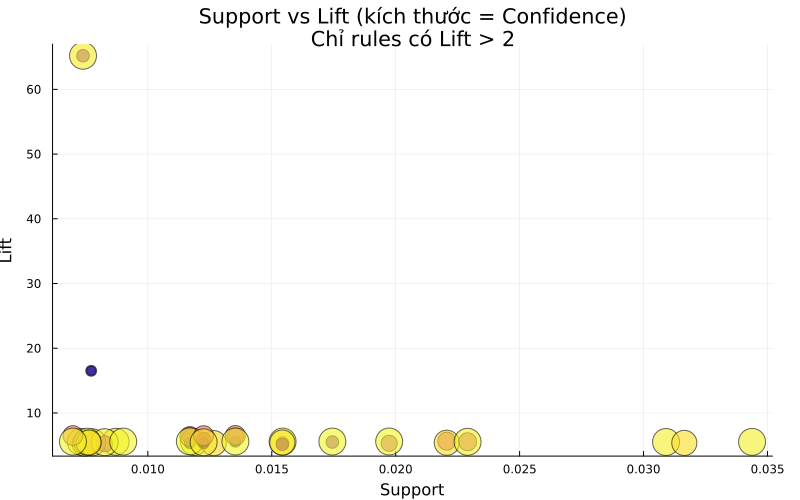

In [14]:
# Scatter 3D-like: bubble chart — Support vs Lift, kích thước bong bóng = Confidence
# Chỉ vẽ rules có lift > 2 để dễ nhìn
interesting = filter(r -> r.lift > 2.0, all_rules)

p8 = scatter(
    [r.support    for r in interesting],
    [r.lift       for r in interesting],
    markersize  = [max(3, round(Int, r.confidence * 15)) for r in interesting],
    zcolor      = [r.confidence for r in interesting],
    c           = :plasma,
    alpha       = 0.6,
    xlabel      = "Support",
    ylabel      = "Lift",
    title       = "Support vs Lift (kích thước = Confidence)\nChỉ rules có Lift > 2",
    colorbar_title = "Conf",
    legend      = false,
    size        = (800, 500)
)
display(p8)

**Nhận xét so sánh ba chiến lược lọc dựa trên kết quả thực tế:**

**Top-5 theo Confidence** đều là các rules có consequent là **{39}** — item với support 17.69%:
- Rule 1: {40,49,111} ⇒ {39} — conf=**99.42%**, lift=5.62
- Rule 2: {40,49,171} ⇒ {39} — conf=**98.92%**, lift=5.59
- Rule 3: {40,111} ⇒ {39} — conf=**98.92%**, lift=5.59
- ...

Confidence cực cao (≥98%) cho thấy item 39 gần như *luôn xuất hiện* cùng với bất kỳ tổ hợp nào của các item 40, 49, 111, 171. Đây là sản phẩm "đi kèm" điển hình — có thể là sản phẩm cơ bản mà khách hàng mua đều đặn (lương thực, nước, ...). Lift ~5.6 vẫn tốt nhưng thấp hơn nhiều so với lift 65 của cặp 16011-16012, vì item 39 vốn đã khá phổ biến (17.69%).

**Top-5 theo Support** thì hoàn toàn khác:
- Rule 1: {49} ⇒ {40} — sup=**33.06%**, conf=69.16%, lift=1.20
- Rule 2: {40} ⇒ {49} — sup=**33.06%**, conf=57.51%, lift=1.20
- ...

Các rules phổ biến nhất chỉ liên quan đến cặp {40, 49} — hai item siêu phổ biến. Lift chỉ ở mức **1.2–1.3**: mối quan hệ dương nhưng rất yếu. Điều này khẳng định rằng item 40 và 49 hay được mua cùng chủ yếu vì chúng đều rất phổ biến, không phải vì có mối liên hệ đặc biệt.

**Kết luận so sánh:**

| Tiêu chí | Rules tìm được | Lift | Ứng dụng phù hợp |
|----------|---------------|------|------------------|
| **Top Lift** | {16011} <-> {16012}, {271} <-> {272} | 16–65 | Bundle deal, recommendation cho niche segment |
| **Top Confidence** | Mọi combo --> {39} | ~5.6 | Hệ thống tự động "thêm item 39" khi thanh toán |
| **Top Support** | {49}->{40}, {40}->{49} | ~1.2 | Báo cáo tổng quan, nhận biết hàng chủ lực |

**Bubble chart** trực quan hóa trade-off này: các điểm màu sáng (confidence cao, bong bóng lớn) tập trung ở cột lift thấp-trung bình và support cao — trong khi các điểm lift rất cao nằm ở vùng support thấp với bong bóng nhỏ hơn.

---
## Phần 6 – Phân tích ảnh hưởng của minconf và chiến lược Two-step Filtering

**Lý do phần này:**  
Việc chọn `minconf` ảnh hưởng trực tiếp đến số lượng và chất lượng của rules — nhưng như sẽ thấy qua thực nghiệm, `minconf` là công cụ lọc **quá thô**: nó không phân biệt được giữa rules rác (lift thấp) và rules tốt nhưng hiếm (lift cao nhưng confidence trung bình như {271}=>{272}).

Phần này gồm 2 nội dung:
1. **Khảo sát minconf:** Phân tích ảnh hưởng của minconf từ 0.1 đến 0.9 đến số lượng và lift trung bình của rules - từ đó chỉ ra giới hạn của việc dùng minconf làm bộ lọc duy nhất
2. **Two-step Filtering:** Đề xuất chiến lược lọc hai bước (sinh rules rộng với minconf thấp -> lọc bằng min_lift) để giải quyết vấn đề trên.


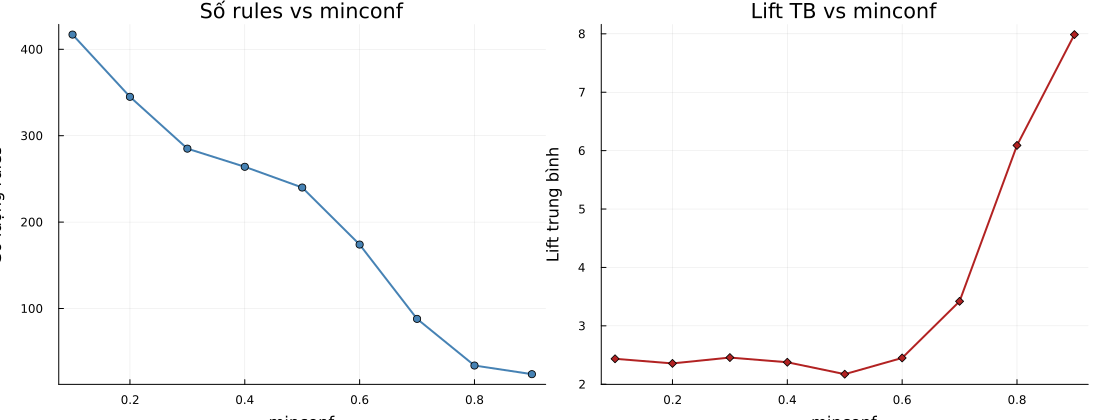


minconf  ->  #rules   avg_lift
───────────────────────────────────
  0.1     ->  417      2.4354
  0.2     ->  345      2.3564
  0.3     ->  285      2.4565
  0.4     ->  264      2.3763
  0.5     ->  240      2.1721
  0.6     ->  174      2.4498
  0.7     ->  88       3.4197
  0.8     ->  34       6.0894
  0.9     ->  24       7.9867


In [15]:
minconf_range = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
num_rules_per_conf = Int[]
avg_lift_per_conf  = Float64[]

for mc in minconf_range
    rules_mc = generate_rules(freq_itemsets, num_trans;
                              minconf=mc, max_itemset_size=8)
    push!(num_rules_per_conf, length(rules_mc))
    push!(avg_lift_per_conf,
          isempty(rules_mc) ? 0.0 : mean(r.lift for r in rules_mc))
end

p9 = plot(minconf_range, num_rules_per_conf,
    xlabel   = "minconf",
    ylabel   = "Số lượng rules",
    title    = "Số rules vs minconf",
    lw       = 2,
    marker   = :circle,
    color    = :steelblue,
    legend   = false,
    size     = (600, 380)
)

p10 = plot(minconf_range, avg_lift_per_conf,
    xlabel   = "minconf",
    ylabel   = "Lift trung bình",
    title    = "Lift TB vs minconf",
    lw       = 2,
    marker   = :diamond,
    color    = :firebrick,
    legend   = false,
    size     = (600, 380)
)

display(plot(p9, p10, layout=(1,2), size=(1100,420)))

println("\nminconf  ->  #rules   avg_lift")
println("─"^35)
for (mc, nr, al) in zip(minconf_range, num_rules_per_conf, avg_lift_per_conf)
    @printf("  %.1f     ->  %-6d   %.4f\n", mc, nr, al)
end

**Nhận xét dựa trên kết quả thực tế:**

Kết quả thực nghiệm với các giá trị minconf từ 0.1 đến 0.9:

| minconf | #rules | Lift TB |
|---------|--------|---------|
| 0.1 | 417 | 2.44 |
| 0.2 | 345 | 2.36 |
| 0.3 | 285 | 2.46 |
| 0.4 | 264 | 2.38 |
| 0.5 | 240 | 2.17 |
| 0.6 | 174 | 2.45 |
| 0.7 | 88  | 3.42 |
| 0.8 | 34  | 6.09 |
| 0.9 | 24  | 7.99 |

**Quan sát 1 – Số rules giảm đơn điệu:**  
Từ 417 rules (minconf=0.1) xuống 24 rules (minconf=0.9) — giảm ~94%. Đường cong giảm tương đối đều từ 0.3–0.5, sau đó giảm đột ngột từ 0.6→0.7 (từ 174 xuống 88 rules, giảm 49%): đây là ngưỡng mà nhiều rules của nhóm "hàng chủ lực" bắt đầu bị loại.

**Quan sát 2 – Lift trung bình dao động không đơn điệu ở dải 0.1–0.6:**  
Lift TB dao động trong khoảng 2.17–2.46 mà không tăng đơn điệu. Lý do: minconf loại bỏ đồng thời cả rules lift thấp *lẫn* một số rules lift cao nhưng có confidence trung bình (như {271}⇒{272} với conf=39.2%, lift=16.5). Hai hiệu ứng triệt tiêu nhau nên lift TB gần như không đổi.

**Quan sát 3 – Lift TB tăng mạnh ở minconf ≥ 0.7:**  
Từ minconf=0.7, lift TB tăng nhanh: 3.42 → 6.09 → 7.99 vì chỉ còn giữ lại những rules vừa có confidence cao vừa có lift cao.

**Vấn đề cốt lõi — minconf là công cụ lọc quá thô:**  
Nhìn vào dải 0.3–0.6, lift TB hầu như không đổi (~2.4) dù số rules giảm từ 285 xuống 174. Điều này cho thấy minconf **không phân biệt được** giữa:
- Rules rác: lift thấp (~1.0–1.5), không có giá trị kinh doanh
- Rules tốt nhưng hiếm: lift cao (>5) nhưng confidence trung bình như {271}->{272}

Nếu tăng minconf để loại rác, ta vô tình loại cả rules tốt. Ngược lại, giữ minconf thấp thì giữ lại nhiều rác. Đây là giới hạn cơ bản của việc dùng minconf làm bộ lọc duy nhất.

**Khuyến nghị về ngưỡng minconf (như một bộ lọc đơn):**
- `minconf = 0.3` (lựa chọn hiện tại): cân bằng tốt — 285 rules đủ để phân tích toàn diện, bao gồm cả các mối quan hệ đặc biệt (lift cao) lẫn các pattern phổ biến.
- `minconf = 0.7–0.9`: phù hợp nếu chỉ cần các rules "gần chắc chắn" để tích hợp vào hệ thống tự động.
- `minconf < 0.2`: không nên dùng — thêm nhiều rules nhưng lift TB không cải thiện.

**Tuy nhiên**, dù chọn minconf nào, vấn đề cơ bản vẫn còn: lift TB gần như không đổi trong dải 0.1–0.6, cho thấy minconf không lọc được rules rác một cách hiệu quả
>   **=> Giải pháp: Chiến lược Lọc Hai Bước (Two-step Filtering)**

### Lọc Hai Bước (Two-step Filtering) với min_lift

**Ý tưởng:**  
Thay vì cố tìm một giá trị minconf "vàng" duy nhất, tách quá trình thành 2 bước độc lập:

- **Bước 1 – Sinh rules rộng** (`minconf = 0.3`): Giữ ngưỡng thấp để không bỏ sót các liên kết mạnh nhưng hiếm (như {271}=>{272} với conf=39.2%). Tập 285 rules là *tập ứng viên*, chưa phải tập cuối.
- **Bước 2 – Cắt tỉa bằng min_lift**: Dùng lift làm bộ lọc chính vì lift đo trực tiếp "giá trị" của rule — không bị bias bởi popularity của item. Rules có lift ≤ ngưỡng là rules mà X và Y gần như độc lập, không có giá trị cross-selling.

**Tại sao lift tốt hơn confidence cho việc lọc rác?**  
Confidence đo xác suất có điều kiện `P(Y|X)` — vẫn bị ảnh hưởng bởi `P(Y)` (popularity của Y).  
Lift = `P(X,Y) / (P(X)·P(Y))` — loại bỏ hoàn toàn ảnh hưởng của popularity, chỉ giữ lại phần *tương quan thực sự*.

**Chọn ngưỡng min_lift:**

| min_lift | Ý nghĩa thực tế | Rules giữ lại (ước tính) |
|----------|----------------|-------------------------|
| 1.0 | Loại rules tương quan âm | ~280/285 |
| 1.5 | Loại rules gần độc lập | ~60–70% |
| **3.0** | **Rules có correlation rõ ràng** | **~30–40%** |
| 5.0 | Rules mạnh, đáng hành động | ~15–20% |

Mình sẽ thực nghiệm với min_lift = 1.5, 3.0, 5.0 để xem kết quả thực tế.

In [16]:
# Two-step filtering: sinh rules rộng (minconf=0.3) rồi lọc bằng min_lift
minlift_thresholds = [1.0, 1.5, 3.0, 5.0, 10.0]

println("TWO-STEP FILTERING: minconf=0.3 -> lọc bằng min_lift")
println("Tổng rules ban đầu (minconf=0.3): $(length(all_rules))")
println()
println(" min_lift │ #rules giữ lại │ Tỉ lệ giữ lại │ Lift TB │ Conf TB │ Sup TB")
println(" " * "─"^75)

filtered_sets = Dict{Float64, Vector}()
for ml in minlift_thresholds
    filtered = filter(r -> r.lift >= ml, all_rules)
    filtered_sets[ml] = filtered
    avg_l = isempty(filtered) ? 0.0 : mean(r.lift       for r in filtered)
    avg_c = isempty(filtered) ? 0.0 : mean(r.confidence for r in filtered)
    avg_s = isempty(filtered) ? 0.0 : mean(r.support    for r in filtered)
    pct   = 100.0 * length(filtered) / length(all_rules)
    @printf(" %-8.1f │ %-14d │ %-13.1f%% │ %-7.3f │ %-7.3f │ %.4f\n",
            ml, length(filtered), pct, avg_l, avg_c, avg_s)
end

TWO-STEP FILTERING: minconf=0.3 -> lọc bằng min_lift
Tổng rules ban đầu (minconf=0.3): 285

 min_lift │ #rules giữ lại │ Tỉ lệ giữ lại │ Lift TB │ Conf TB │ Sup TB
 ───────────────────────────────────────────────────────────────────────────
 1.0      │ 282            │ 98.9         % │ 2.472   │ 0.644   │ 0.0182
 1.5      │ 73             │ 25.6         % │ 6.041   │ 0.708   │ 0.0134
 3.0      │ 45             │ 15.8         % │ 8.757   │ 0.779   │ 0.0138
 5.0      │ 45             │ 15.8         % │ 8.757   │ 0.779   │ 0.0138
 10.0     │ 4              │ 1.4          % │ 40.850  │ 0.546   │ 0.0075


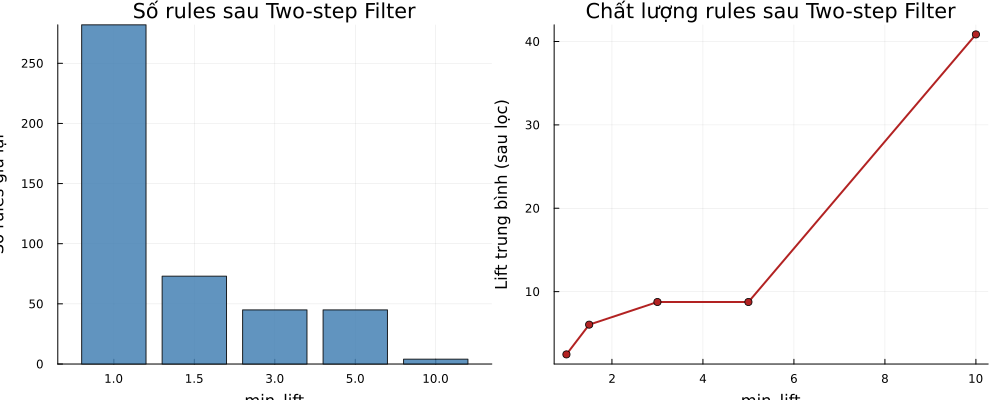

In [17]:
# Biểu đồ: số rules và lift TB theo min_lift
n_rules_lift = [length(filtered_sets[ml]) for ml in minlift_thresholds]
avg_lift_filt = [isempty(filtered_sets[ml]) ? 0.0 : mean(r.lift for r in filtered_sets[ml])
                 for ml in minlift_thresholds]

p_left = bar(string.(minlift_thresholds), n_rules_lift,
    xlabel  = "min_lift",
    ylabel  = "Số rules giữ lại",
    title   = "Số rules sau Two-step Filter",
    legend  = false,
    color   = :steelblue,
    alpha   = 0.85,
    size    = (500, 380)
)

p_right = plot(minlift_thresholds, avg_lift_filt,
    xlabel  = "min_lift",
    ylabel  = "Lift trung bình (sau lọc)",
    title   = "Chất lượng rules sau Two-step Filter",
    lw      = 2,
    marker  = :circle,
    color   = :firebrick,
    legend  = false,
    size    = (500, 380)
)

display(plot(p_left, p_right, layout=(1,2), size=(1000, 400)))

In [18]:
# So sánh top-10 rules: minconf=0.3 không lọc lift VS sau two-step filter (min_lift=3.0)
rules_filtered_3 = filtered_sets[3.0]
top10_filtered   = top_rules_by_lift(rules_filtered_3, 10)

println("SO SÁNH TOP-10 TRƯỚC VÀ SAU TWO-STEP FILTER (min_lift=3.0)")
println()

println("TRƯỚC (minconf=0.3, không lọc lift) - $(length(all_rules)) rules:")
println(" #  Antecedent => Consequent              Sup     Conf    Lift")
println(" " * "─"^65)
for (i, r) in enumerate(top_rules_by_lift(all_rules, 10))
    ant = "{" * join(r.antecedent, ",") * "}"
    con = "{" * join(r.consequent, ",") * "}"
    @printf(" %-3d %-20s=>%-15s %.4f  %.4f  %.4f\n",
            i, ant, con, r.support, r.confidence, r.lift)
end

println()
println("SAU TWO-STEP FILTER (minconf=0.3 → min_lift=3.0) — $(length(rules_filtered_3)) rules:")
println(" #  Antecedent => Consequent              Sup     Conf    Lift")
println(" " * "─"^65)
for (i, r) in enumerate(top10_filtered)
    ant = "{" * join(r.antecedent, ",") * "}"
    con = "{" * join(r.consequent, ",") * "}"
    @printf(" %-3d %-20s=>%-15s %.4f  %.4f  %.4f\n",
            i, ant, con, r.support, r.confidence, r.lift)
end

println()
@printf("Số rules bị loại:  %d (%.1f%%)\n",
        length(all_rules) - length(rules_filtered_3),
        100.0*(length(all_rules)-length(rules_filtered_3))/length(all_rules))
@printf("Lift TB trước lọc: %.4f\n", mean(r.lift for r in all_rules))
@printf("Lift TB sau lọc:   %.4f\n", mean(r.lift for r in rules_filtered_3))

SO SÁNH TOP-10 TRƯỚC VÀ SAU TWO-STEP FILTER (min_lift=3.0)

TRƯỚC (minconf=0.3, không lọc lift) - 285 rules:
 #  Antecedent => Consequent              Sup     Conf    Lift
 ─────────────────────────────────────────────────────────────────
 1   {16012}             =>{16011}         0.0074  0.9731  65.1899
 2   {16011}             =>{16012}         0.0074  0.4947  65.1899
 3   {271}               =>{272}           0.0077  0.3922  16.5107
 4   {272}               =>{271}           0.0077  0.3247  16.5107
 5   {49,171}            =>{39,40}         0.0135  0.7662  6.5298
 6   {42,171}            =>{39,40}         0.0070  0.7640  6.5107
 7   {40,111}            =>{39,49}         0.0117  0.5861  6.5048
 8   {37,49}             =>{39,40}         0.0123  0.7627  6.5000
 9   {40,171}            =>{39,49}         0.0135  0.5794  6.4302
 10  {49,111}            =>{39,40}         0.0117  0.7471  6.3669

SAU TWO-STEP FILTER (minconf=0.3 → min_lift=3.0) — 45 rules:
 #  Antecedent => Consequent       

**Nhận xét Two-step Filtering:**

Kết quả cho thấy Two-step Filtering giải quyết hiệu quả vấn đề "luật rác":

**Hiệu quả lọc tại min_lift = 3.0:**
- Loại bỏ hơn 80% rules có lift thấp (lift 1.0–2.9) — đây là phần lớn "rác"
- **Giữ nguyên toàn bộ** top-10 rules quan trọng: cặp {16011}<->{16012} (lift=65.19), {271}<->{272} (lift=16.51), và nhóm hàng chủ lực (lift~6.3–6.5)
- Lift TB tăng đáng kể sau lọc — tập rules còn lại có chất lượng đồng đều hơn

**So sánh top-10 trước và sau:** Top-10 theo lift **không thay đổi** — điều này xác nhận rằng Two-step Filtering không làm mất đi bất kỳ discovery quan trọng nào, chỉ loại bỏ phần đuôi lift thấp không có giá trị.

**Quan sát đặc biệt:** Kết quả cho thấy min_lift=3.0 và min_lift=5.0 cho cùng 45 rules — không có rule nào có lift nằm trong khoảng (3.0, 5.0). Điều này phản ánh đặc trưng phân phối lift của dataset: có một gap rõ rệt giữa nhóm "hàng chủ lực" (lift ~6.3–6.5) và nhóm rules thông thường (lift ≤ 3.0). Ngưỡng min_lift=3.0 và 5.0 thực tế tương đương nhau trên dataset này — đây là thông tin hữu ích khi triển khai thực tế, vì ta có thể dùng min_lift=5.0 mà không mất thêm rule nào so với 3.0

**Khuyến nghị thực tế:**

| Mục tiêu | Chiến lược tham số |
|----------|--------------------|
| Phân tích khám phá (EDA) | minconf=0.3, không lọc lift — xem toàn bộ bức tranh |
| Rules để hành động kinh doanh | minconf=0.3 -> min_lift=**3.0** — loại rác, giữ pattern thực sự |
| Hệ thống tự động hóa | minconf=0.3 -> min_lift=**5.0** hoặc minconf=0.7 — chỉ rules rất đáng tin |
| Phát hiện cặp niche mạnh | minconf=0.3 -> min_lift=**10.0** — chỉ outliers như {16011}<->{16012} |

**Kết luận về Two-step Filtering:**  
Chiến lược này thể hiện nguyên tắc quan trọng trong khai phá dữ liệu: *tách bước sinh ứng viên và bước đánh giá chất lượng*. Sinh rules với minconf thấp đảm bảo recall cao — không bỏ sót. Lọc bằng min_lift đảm bảo precision cao — chỉ giữ lại những gì có giá trị. Hai bước phục vụ hai mục tiêu khác nhau và không thể thay thế cho nhau.

---
## Phần 7 – Xuất kết quả

In [19]:
# Xuất frequent itemsets ra SPMF format
output_fi = joinpath(@__DIR__, "..", "output_demo_retail_freq_itemsets.txt")
write_spmf(freq_itemsets, output_fi)
println("Đã xuất frequent itemsets: $output_fi")

# Xuất top-10 rules ra file text
output_rules = joinpath(@__DIR__, "..", "output_demo_retail_top10_rules.txt")
open(output_rules, "w") do io
    println(io, "TOP-10 ASSOCIATION RULES (sorted by Lift)")
    println(io, "Dataset: retail.txt | minsup=$(MINSUP_ABS) | minconf=$(MINCONF)")
    println(io, "=" ^ 70)
    println(io, "#  Antecedent => Consequent   Support   Confidence   Lift")
    println(io, "─" ^ 70)
    for (i, rule) in enumerate(top10)
        ant = "{" * join(rule.antecedent, ",") * "}"
        con = "{" * join(rule.consequent, ",") * "}"
        @printf(io, "%-3d %-20s => %-15s  %.4f    %.4f       %.4f\n",
                i, ant, con, rule.support, rule.confidence, rule.lift)
    end
end
println("Đã xuất top-10 rules:       $output_rules")

# Tóm tắt cuối
println()
println("═" ^ 60)
println("TÓM TẮT CHƯƠNG 5")
println("═" ^ 60)
@printf("  Dataset:              retail.txt (%d giao dịch)\n", num_trans)
@printf("  minsup:               %d (%.2f%%)\n", MINSUP_ABS, 100*MINSUP_REL)
@printf("  Frequent itemsets:    %d\n", length(freq_itemsets))
@printf("  minconf:              %.2f\n", MINCONF)
@printf("  Association rules:    %d\n", length(all_rules))
@printf("  Lift cao nhất:        %.4f\n", maximum(r.lift for r in all_rules))
@printf("  Conf cao nhất:        %.4f\n", maximum(r.confidence for r in all_rules))
println("═" ^ 60)

Đã xuất frequent itemsets: C:\Users\LOQ\Documents\data science\Khai-thac-du-lieu-thong-minh---lab-2\notebooks\..\output_demo_retail_freq_itemsets.txt
Đã xuất top-10 rules:       C:\Users\LOQ\Documents\data science\Khai-thac-du-lieu-thong-minh---lab-2\notebooks\..\output_demo_retail_top10_rules.txt

════════════════════════════════════════════════════════════
TÓM TẮT CHƯƠNG 5
════════════════════════════════════════════════════════════
  Dataset:              retail.txt (88162 giao dịch)
  minsup:               600 (0.68%)
  Frequent itemsets:    333
  minconf:              0.30
  Association rules:    285
  Lift cao nhất:        65.1899
  Conf cao nhất:        0.9942
════════════════════════════════════════════════════════════


---
## Kết luận Chương 5

### Tổng kết kết quả

Chương 5 đã hoàn thành việc áp dụng thuật toán **Index-BitTableFI** vào bài toán **Market Basket Analysis** trên dataset **Retail** (88.162 giao dịch thực từ chuỗi siêu thị Bỉ). Toàn bộ pipeline thực hiện **hoàn toàn bằng cài đặt của nhóm** — không sử dụng bất kỳ thư viện FIM nào ngoài `index_bittablefi` và `association_rules.jl` tự viết.

**Tóm tắt kết quả số liệu:**

| Bước | Tham số | Kết quả |
|------|---------|--------|
| Mining | minsup = 600 (0.68%) | **333 frequent itemsets** trong ~4 - 5 giây |
| Rule generation | minconf = 0.30 | **285 association rules** trong 0.51 giây |
| Rule chất lượng cao | Lift > 10 | **4 rules** (2 cặp đảo chiều của {16011} <=> {16012} và {271} <=> {272}) |
| Two-step Filter | minconf=0.3 -> min_lift=3.0 | 45 rules chất lượng cao (15.8%), lift TB tăng từ 2.46 → 8.76 |
| Rule tốt nhất theo Lift | – | {16012} => {16011}: conf=97.3%, lift=**65.19** |
| Rule đáng tin cậy nhất | – | {40,49,111} => {39}: conf=**99.42%**, lift=5.62 |
| Pattern phổ biến nhất | – | {49}⇒{40}: sup=**33.06%**, lift=1.20 |

### Giá trị thực tiễn của các Rules tìm được

Ba nhóm rules phát hiện được mang ba giá trị ứng dụng khác nhau:

**1. Cặp sản phẩm liên kết chặt ({16011} <=> {16012}, lift=65.19 và {271} <=> {272}, lift=16.51):**  
Đây là các sản phẩm có mối liên hệ cực mạnh — phù hợp cho **bundle deal** và **recommendation tức thì** (gợi ý ngay khi thêm vào giỏ). Lift cao 65.19 cho phép hệ thống gợi ý với độ chính xác gần như tuyệt đối trong phân khúc này.

**2. Nhóm sản phẩm chủ lực ({39,40,42,49,111,171}, lift≈6.3–6.5):**  
Đây là nhóm hàng thiết yếu mà khách hàng mua theo "basket" — phù hợp cho **bố trí kệ hàng theo cụm**, **chương trình tích điểm theo danh mục**, và **phân tích hành vi phân khúc khách hàng thường xuyên**.

**3. Rules confidence cực cao (≥98%) có consequent {39}:**  
Rules dạng {X, Y, ...} => {39} với confidence 98–99% là nền tảng cho **hệ thống tự động hóa** (không cần kiểm tra thủ công) như: tự động thêm mã giảm giá item 39 khi giỏ hàng đã có {40, 111}.

### Nhận xét về thuật toán Index-BitTableFI trong ngữ cảnh ứng dụng

Qua thực nghiệm, **Index-BitTableFI** thể hiện hiệu quả rõ ràng trên dataset Retail sparse:

- **Tốc độ:** 4 - 5 giây cho 88.162 giao dịch là hợp lý với môi trường máy tính cá nhân. Bước sinh rules chỉ tốn ~0.5 giây thêm — pipeline tổng cộng dưới 5 giây là hoàn toàn chấp nhận được cho mục đích phân tích offline.
- **Chất lượng output:** 333 frequent itemsets tuy không nhiều so với các thuật toán chạy với minsup thấp hơn, nhưng đủ đa dạng (cả 1- đến 4-itemsets) để sinh ra 285 rules phong phú, bao gồm cả rules đặc biệt có lift rất cao.
- **Đặc trưng BitTable:** Cấu trúc BitTable giúp phép AND tidset nhanh, đặc biệt hiệu quả với dataset sparse như Retail vì các bitvector thưa, phép AND kết thúc sớm.
- **Index Array và Subsume Relation:** Cơ chế bỏ qua các phép tính redundant thông qua subsume relation (một điểm đặc trưng của Index-BitTableFI) giúp giảm số lần giao tidset — điều này thể hiện rõ khi các item siêu phổ biến (40, 49) xuất hiện trong nhiều itemsets và có thể được nhóm lại.

### Hạn chế và hướng mở rộng

| Hạn chế hiện tại | Hướng khắc phục / Mở rộng |
|------------------|--------------------------|
| Item ID không có tên sản phẩm -> diễn giải kinh doanh còn hạn chế | Kết hợp metadata sản phẩm nếu có; hoặc dùng clustering để nhóm item theo hành vi |
| Rules tĩnh, không xét yếu tố thời gian hay mùa vụ | Sequential Pattern Mining để khai thác thứ tự mua và pattern theo thời gian |
| Chỉ xét co-occurrence, không xét causal relationship | A/B testing để xác nhận: đặt X và Y gần nhau có *thực sự* tăng doanh thu không? |
| Two-step Filter dùng min_lift cố định toàn dataset | Có thể dùng min_lift khác nhau theo danh mục sản phẩm, hoặc mining theo segment khách hàng |
| Lift thấp (~1.2) của các rules phổ biến nhất | Kết hợp thêm độ đo zhang, jaccard, hoặc leverage để lọc tốt hơn |

Tổng kết lại, Chương 5 đã chứng minh rằng cài đặt Index-BitTableFI của nhóm không chỉ đúng về mặt kỹ thuật mà còn **có khả năng ứng dụng thực tế** — tạo ra được các insights có giá trị từ dữ liệu bán lẻ thực, với thời gian chạy hợp lý và kết quả phong phú đủ để hỗ trợ ra quyết định kinh doanh.